In [27]:
import pandas as pd, glob

files = glob.glob("../noaa_data_pipeline/data/ndbc/station=44017/**/*.parquet", recursive=True)
df_44017 = pd.concat([pd.read_parquet(f) for f in sorted(files)], ignore_index=True)
df_44017.head(100)


,timestamp,station_id,WD,wind_speed_ms,wind_gust_ms,wave_height_m,dominant_wave_period_s,avg_wave_period_s,wave_direction_deg,BAR,air_temp_c,water_temp_c,dewpoint_c,visibility_nm,water_level_ft,wind_direction_deg,air_pressure_hpa
0,2002-09-01 01:00:00,44017,19.0,2.0,4.3,0.00,0.00,0.00,NaN,1034.3,15.1,NaN,9.9,NaN,NaN,NaN,NaN
1,2002-09-01 02:00:00,44017,10.0,1.6,2.9,0.00,0.00,0.00,NaN,1034.2,14.9,NaN,10.9,NaN,NaN,NaN,NaN
2,2002-09-01 03:00:00,44017,8.0,1.3,2.4,0.00,0.00,0.00,NaN,1033.8,14.6,NaN,11.4,NaN,NaN,NaN,NaN
3,2002-09-01 04:00:00,44017,6.0,1.3,2.5,0.00,0.00,0.00,NaN,1033.5,14.3,NaN,11.6,NaN,NaN,NaN,NaN
4,2002-09-01 05:00:00,44017,33.0,1.6,4.2,0.00,0.00,0.00,NaN,1032.9,14.6,NaN,11.1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2002-09-05 00:00:00,44017,260.0,3.8,4.4,0.95,8.33,5.49,NaN,1012.0,21.0,20.4,20.9,NaN,NaN,NaN,NaN
96,2002-09-05 01:00:00,44017,268.0,3.3,3.8,0.96,9.09,5.48,NaN,1012.7,21.0,20.2,20.8,NaN,NaN,NaN,NaN
97,2002-09-05 02:00:00,44017,281.0,3.4,3.8,0.90,9.09,5.38,NaN,1013.2,20.9,20.2,20.4,NaN,NaN,NaN,NaN
98,2002-09-05 03:00:00,44017,314.0,5.2,5.9,0.85,9.09,5.60,NaN,1013.4,22.7,20.1,16.9,NaN,NaN,NaN,NaN


In [28]:
# Merge all NDBC stations into one timestamp-based dataframe
files = glob.glob("../noaa_data_pipeline/data/ndbc/station=*/**/*.parquet", recursive=True)
df_all = pd.concat([pd.read_parquet(f) for f in sorted(files)], ignore_index=True)

#df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce")
feature_cols = [c for c in df_all.columns if c not in ["timestamp", "station_id"]]

for col in feature_cols:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

df_merged = (
    df_all.groupby("timestamp", as_index=False)[feature_cols]
    .mean()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

df_merged.head(100)

,timestamp,WD,wind_speed_ms,wind_gust_ms,wave_height_m,dominant_wave_period_s,avg_wave_period_s,wave_direction_deg,BAR,air_temp_c,water_temp_c,dewpoint_c,visibility_nm,water_level_ft,wind_direction_deg,air_pressure_hpa
0,1999-01-27 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999-01-27 02:00:00,249.0,5.7,NaN,0.58,3.45,3.87,261.0,NaN,5.2,NaN,-0.8,NaN,NaN,NaN,NaN
2,1999-01-27 03:00:00,253.0,6.2,7.1,0.59,3.45,3.72,253.0,NaN,5.5,7.0,-0.6,NaN,NaN,NaN,NaN
3,1999-01-27 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1999-01-27 05:00:00,254.0,7.8,9.0,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1999-01-31 00:00:00,353.0,10.5,12.2,0.85,3.45,3.76,353.0,1032.5,0.6,6.4,NaN,NaN,NaN,NaN,NaN
96,1999-01-31 01:00:00,347.0,11.1,13.3,1.21,4.17,4.03,1.0,1033.3,0.5,6.4,-5.2,NaN,NaN,NaN,NaN
97,1999-01-31 02:00:00,352.0,12.9,16.1,1.65,5.00,4.38,356.0,1033.6,0.0,6.3,-7.5,NaN,NaN,NaN,NaN
98,1999-01-31 03:00:00,353.0,12.9,15.8,1.72,5.26,4.49,1.0,1034.6,-0.4,6.3,-9.2,NaN,NaN,NaN,NaN


In [29]:
print(df_merged.info())
df_merged.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575097 entries, 0 to 575096
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   timestamp               575097 non-null  datetime64[ns]
 1   WD                      68653 non-null   float64       
 2   wind_speed_ms           571351 non-null  float64       
 3   wind_gust_ms            571319 non-null  float64       
 4   wave_height_m           274334 non-null  float64       
 5   dominant_wave_period_s  274167 non-null  float64       
 6   avg_wave_period_s       274334 non-null  float64       
 7   wave_direction_deg      268699 non-null  float64       
 8   BAR                     68651 non-null   float64       
 9   air_temp_c              504059 non-null  float64       
 10  water_temp_c            552152 non-null  float64       
 11  dewpoint_c              491780 non-null  float64       
 12  visibility_nm           0 non-

timestamp                      0
WD                        506444
wind_speed_ms               3746
wind_gust_ms                3778
wave_height_m             300763
dominant_wave_period_s    300930
avg_wave_period_s         300763
wave_direction_deg        306398
BAR                       506446
air_temp_c                 71038
water_temp_c               22945
dewpoint_c                 83317
visibility_nm             575097
water_level_ft            575097
wind_direction_deg        125232
air_pressure_hpa           70867
dtype: int64

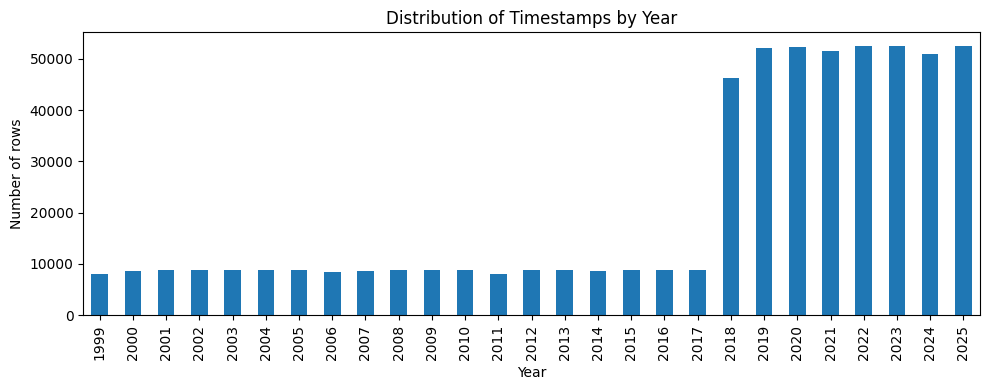

In [30]:
import matplotlib.pyplot as plt

# replace df_merged with your dataframe name (e.g., df_44017, df_all, etc.)
# = pd.to_datetime(df_merged["timestamp"], errors="coerce")

year_counts = df_merged["timestamp"].dt.year.value_counts(dropna=True).sort_index()

ax = year_counts.plot(kind="bar", figsize=(10, 4))
ax.set_title("Distribution of Timestamps by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of rows")
plt.tight_layout()
plt.show()

In [31]:
df_merged.tail(100)

,timestamp,WD,wind_speed_ms,wind_gust_ms,wave_height_m,dominant_wave_period_s,avg_wave_period_s,wave_direction_deg,BAR,air_temp_c,water_temp_c,dewpoint_c,visibility_nm,water_level_ft,wind_direction_deg,air_pressure_hpa
574997,2025-12-31 07:20:00,NaN,12.20,15.60,NaN,NaN,NaN,NaN,NaN,-0.50,8.05,-7.90,NaN,NaN,290.5,1009.85
574998,2025-12-31 07:30:00,NaN,11.55,15.00,NaN,NaN,NaN,NaN,NaN,-0.45,8.05,-7.75,NaN,NaN,292.0,1009.85
574999,2025-12-31 07:40:00,NaN,11.75,15.50,1.15,4.55,3.93,305.0,NaN,-0.45,8.10,-7.55,NaN,NaN,294.0,1009.90
575000,2025-12-31 07:50:00,NaN,11.70,15.35,NaN,NaN,NaN,NaN,NaN,-0.60,8.15,-8.15,NaN,NaN,296.0,1009.75
575001,2025-12-31 08:00:00,NaN,11.55,16.35,NaN,NaN,NaN,NaN,NaN,-0.50,8.15,-7.80,NaN,NaN,290.0,1009.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575092,2025-12-31 23:10:00,NaN,8.90,11.60,0.85,3.23,3.33,263.0,NaN,0.90,8.25,-6.60,NaN,NaN,249.0,1009.60
575093,2025-12-31 23:20:00,NaN,8.45,11.55,NaN,NaN,NaN,NaN,NaN,1.00,8.25,-6.35,NaN,NaN,252.5,1009.65
575094,2025-12-31 23:30:00,NaN,9.20,12.05,NaN,NaN,NaN,NaN,NaN,1.00,8.25,-6.40,NaN,NaN,250.5,1009.70
575095,2025-12-31 23:40:00,NaN,9.15,12.25,0.87,3.13,3.40,269.0,NaN,1.00,8.30,-6.45,NaN,NaN,251.0,1009.70


In [32]:
df_merged = df_merged[df_merged["timestamp"].dt.year >= 2014]
df_merged = df_merged[df_merged["timestamp"].dt.month >= 2]

df_merged.head(100)

,timestamp,WD,wind_speed_ms,wind_gust_ms,wave_height_m,dominant_wave_period_s,avg_wave_period_s,wave_direction_deg,BAR,air_temp_c,water_temp_c,dewpoint_c,visibility_nm,water_level_ft,wind_direction_deg,air_pressure_hpa
130195,2014-02-01 00:50:00,NaN,5.30,6.35,0.93,9.09,4.67,125.0,NaN,3.90,4.55,-1.9,NaN,NaN,281.0,1022.05
130196,2014-02-01 01:50:00,NaN,5.50,6.35,0.93,10.81,4.67,130.0,NaN,3.60,4.55,-4.4,NaN,NaN,283.0,1022.70
130197,2014-02-01 02:50:00,NaN,4.25,5.15,0.87,10.81,4.58,146.0,NaN,3.50,4.50,-4.7,NaN,NaN,269.5,1023.20
130198,2014-02-01 03:50:00,NaN,4.55,5.55,0.83,9.09,5.02,124.0,NaN,3.75,4.45,-5.1,NaN,NaN,279.5,1023.85
130199,2014-02-01 04:50:00,NaN,4.30,4.85,0.81,10.81,5.27,NaN,NaN,3.55,4.40,-5.1,NaN,NaN,262.0,1024.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130290,2014-02-04 23:50:00,NaN,1.30,2.20,0.97,7.14,6.32,NaN,NaN,1.25,4.25,-4.7,NaN,NaN,47.0,1029.30
130291,2014-02-05 00:50:00,NaN,2.65,3.60,0.94,7.14,6.22,109.0,NaN,1.30,4.40,-4.3,NaN,NaN,60.0,1028.70
130292,2014-02-05 01:50:00,NaN,1.90,2.45,0.88,7.14,6.14,115.0,NaN,1.45,4.40,-4.5,NaN,NaN,54.5,1028.80
130293,2014-02-05 02:50:00,NaN,3.70,4.75,0.86,7.14,6.24,106.0,NaN,1.60,4.35,-3.7,NaN,NaN,65.5,1027.55


In [33]:
# Round to nearest hour while keeping only one row per hour:
# 1) prefer exact-hour timestamps,
# 2) otherwise keep the closest timestamp to that hour.
df_tmp = df_merged.copy()
df_tmp["timestamp"] = pd.to_datetime(df_tmp["timestamp"], errors="coerce")

df_tmp["_rounded_hour"] = df_tmp["timestamp"].dt.round("h")
df_tmp["_is_exact_hour"] = df_tmp["timestamp"].eq(df_tmp["_rounded_hour"])
df_tmp["_distance_to_hour_s"] = (
    df_tmp["timestamp"].sub(df_tmp["_rounded_hour"]).abs().dt.total_seconds()
 )

df_merged = (
    df_tmp.sort_values(
        ["_rounded_hour", "_is_exact_hour", "_distance_to_hour_s", "timestamp"],
        ascending=[True, False, True, True],
    )
    .drop_duplicates(subset=["_rounded_hour"], keep="first")
    .assign(timestamp=lambda d: d["_rounded_hour"])
    .drop(columns=["_rounded_hour", "_is_exact_hour", "_distance_to_hour_s"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

df_merged.head(100)

,timestamp,WD,wind_speed_ms,wind_gust_ms,wave_height_m,dominant_wave_period_s,avg_wave_period_s,wave_direction_deg,BAR,air_temp_c,water_temp_c,dewpoint_c,visibility_nm,water_level_ft,wind_direction_deg,air_pressure_hpa
0,2014-02-01 01:00:00,NaN,5.30,6.35,0.93,9.09,4.67,125.0,NaN,3.90,4.55,-1.9,NaN,NaN,281.0,1022.05
1,2014-02-01 02:00:00,NaN,5.50,6.35,0.93,10.81,4.67,130.0,NaN,3.60,4.55,-4.4,NaN,NaN,283.0,1022.70
2,2014-02-01 03:00:00,NaN,4.25,5.15,0.87,10.81,4.58,146.0,NaN,3.50,4.50,-4.7,NaN,NaN,269.5,1023.20
3,2014-02-01 04:00:00,NaN,4.55,5.55,0.83,9.09,5.02,124.0,NaN,3.75,4.45,-5.1,NaN,NaN,279.5,1023.85
4,2014-02-01 05:00:00,NaN,4.30,4.85,0.81,10.81,5.27,NaN,NaN,3.55,4.40,-5.1,NaN,NaN,262.0,1024.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2014-02-05 00:00:00,NaN,1.30,2.20,0.97,7.14,6.32,NaN,NaN,1.25,4.25,-4.7,NaN,NaN,47.0,1029.30
96,2014-02-05 01:00:00,NaN,2.65,3.60,0.94,7.14,6.22,109.0,NaN,1.30,4.40,-4.3,NaN,NaN,60.0,1028.70
97,2014-02-05 02:00:00,NaN,1.90,2.45,0.88,7.14,6.14,115.0,NaN,1.45,4.40,-4.5,NaN,NaN,54.5,1028.80
98,2014-02-05 03:00:00,NaN,3.70,4.75,0.86,7.14,6.24,106.0,NaN,1.60,4.35,-3.7,NaN,NaN,65.5,1027.55


In [34]:
print(df_merged.info())
df_merged.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95626 entries, 0 to 95625
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   timestamp               95626 non-null  datetime64[ns]
 1   WD                      0 non-null      float64       
 2   wind_speed_ms           92741 non-null  float64       
 3   wind_gust_ms            92741 non-null  float64       
 4   wave_height_m           32472 non-null  float64       
 5   dominant_wave_period_s  32467 non-null  float64       
 6   avg_wave_period_s       32472 non-null  float64       
 7   wave_direction_deg      31769 non-null  float64       
 8   BAR                     0 non-null      float64       
 9   air_temp_c              84430 non-null  float64       
 10  water_temp_c            91601 non-null  float64       
 11  dewpoint_c              81917 non-null  float64       
 12  visibility_nm           0 non-null      float6

timestamp                     0
WD                        95626
wind_speed_ms              2885
wind_gust_ms               2885
wave_height_m             63154
dominant_wave_period_s    63159
avg_wave_period_s         63154
wave_direction_deg        63857
BAR                       95626
air_temp_c                11196
water_temp_c               4025
dewpoint_c                13709
visibility_nm             95626
water_level_ft            95626
wind_direction_deg        11057
air_pressure_hpa            711
dtype: int64

In [35]:
df_merged = df_merged[["timestamp", "wind_speed_ms", "wind_gust_ms", "air_temp_c", "water_temp_c", "dewpoint_c", "wind_direction_deg", "air_pressure_hpa"]]
df_merged.head(100)


,timestamp,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa
0,2014-02-01 01:00:00,5.30,6.35,3.90,4.55,-1.9,281.0,1022.05
1,2014-02-01 02:00:00,5.50,6.35,3.60,4.55,-4.4,283.0,1022.70
2,2014-02-01 03:00:00,4.25,5.15,3.50,4.50,-4.7,269.5,1023.20
3,2014-02-01 04:00:00,4.55,5.55,3.75,4.45,-5.1,279.5,1023.85
4,2014-02-01 05:00:00,4.30,4.85,3.55,4.40,-5.1,262.0,1024.05
...,...,...,...,...,...,...,...,...
95,2014-02-05 00:00:00,1.30,2.20,1.25,4.25,-4.7,47.0,1029.30
96,2014-02-05 01:00:00,2.65,3.60,1.30,4.40,-4.3,60.0,1028.70
97,2014-02-05 02:00:00,1.90,2.45,1.45,4.40,-4.5,54.5,1028.80
98,2014-02-05 03:00:00,3.70,4.75,1.60,4.35,-3.7,65.5,1027.55


In [36]:
print(df_merged.info())
df_merged.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95626 entries, 0 to 95625
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           95626 non-null  datetime64[ns]
 1   wind_speed_ms       92741 non-null  float64       
 2   wind_gust_ms        92741 non-null  float64       
 3   air_temp_c          84430 non-null  float64       
 4   water_temp_c        91601 non-null  float64       
 5   dewpoint_c          81917 non-null  float64       
 6   wind_direction_deg  84569 non-null  float64       
 7   air_pressure_hpa    94915 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 5.8 MB
None


timestamp                 0
wind_speed_ms          2885
wind_gust_ms           2885
air_temp_c            11196
water_temp_c           4025
dewpoint_c            13709
wind_direction_deg    11057
air_pressure_hpa        711
dtype: int64

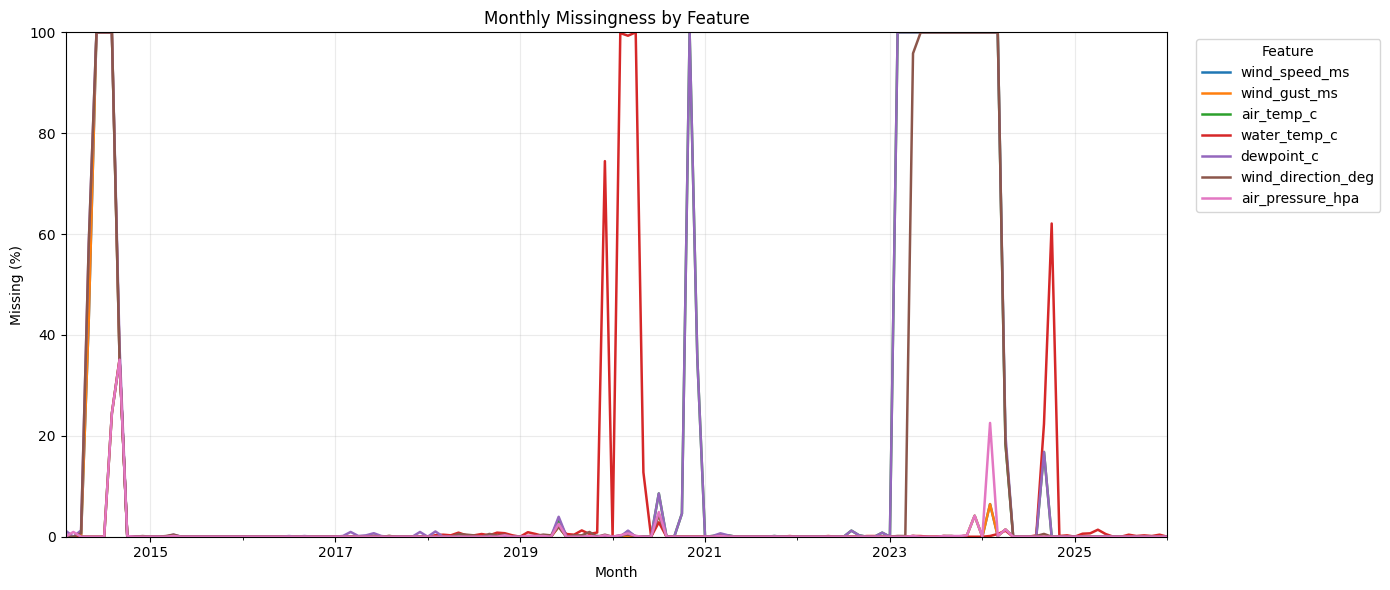

In [37]:
# Ensure timestamp is datetime and sorted
df_plot = df_merged.copy()
df_plot["timestamp"] = pd.to_datetime(df_plot["timestamp"], errors="coerce")
df_plot = df_plot.dropna(subset=["timestamp"]).sort_values("timestamp")

# Monthly % missing per feature
monthly_null_pct = (
    df_plot.set_index("timestamp")
           .drop(columns=["station_id"], errors="ignore")  # if present
           .isna()
           .resample("MS")   # month start
           .mean()
           .mul(100)
)

# Plot
ax = monthly_null_pct.plot(figsize=(14, 6), linewidth=1.8)
ax.set_title("Monthly Missingness by Feature")
ax.set_xlabel("Month")
ax.set_ylabel("Missing (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.25)
ax.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


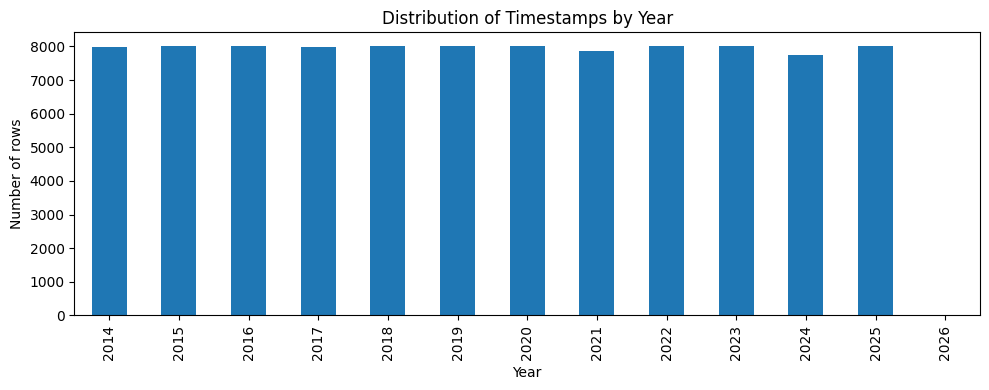

In [38]:
import matplotlib.pyplot as plt

# replace df_merged with your dataframe name (e.g., df_44017, df_all, etc.)
# = pd.to_datetime(df_merged["timestamp"], errors="coerce")

year_counts = df_merged["timestamp"].dt.year.value_counts(dropna=True).sort_index()

ax = year_counts.plot(kind="bar", figsize=(10, 4))
ax.set_title("Distribution of Timestamps by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of rows")
plt.tight_layout()
plt.show()

In [39]:
df_merged.tail(100)

,timestamp,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa
95526,2025-12-27 21:00:00,6.40,8.75,0.30,7.80,-2.30,6.0,1020.85
95527,2025-12-27 22:00:00,5.75,7.30,0.35,7.80,-2.70,6.5,1021.55
95528,2025-12-27 23:00:00,5.25,6.85,0.25,7.80,-2.85,181.0,1022.15
95529,2025-12-28 00:00:00,5.10,6.70,0.30,7.70,-2.85,171.5,1023.05
95530,2025-12-28 01:00:00,5.10,6.80,0.55,7.80,-2.75,351.0,1022.80
...,...,...,...,...,...,...,...,...
95621,2025-12-31 20:00:00,8.75,11.55,0.60,8.05,-6.90,265.5,1008.85
95622,2025-12-31 21:00:00,9.25,11.50,0.95,8.20,-6.35,264.5,1008.95
95623,2025-12-31 22:00:00,8.35,11.15,0.75,8.30,-6.75,256.0,1009.10
95624,2025-12-31 23:00:00,8.45,10.70,1.00,8.25,-6.40,254.5,1009.55


In [41]:
df_merged.to_csv('../data/processed/ndbc_data_processed.csv', index=False)